In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns

from dpks import QuantMatrix

In [37]:

def preprocess_design_matrix(design_matrix, col):

    design_matrix['group'] = np.where(
        design_matrix[col] > design_matrix[col].mean(), 2, 1
    )

    design_matrix['sample'] = design_matrix['injection']

    return design_matrix

In [38]:
def preprocess_data(raw_data, design_matrix):

    quant_matrix = QuantMatrix(
        quantification_file=raw_data[['Protein'] + [sample for sample in design_matrix['sample'].values]].copy(),
        design_matrix_file=design_matrix,
        annotation_fasta_file="../0_data/2023-04-24-UP000005640.fas"
    )

    quant_data = quant_matrix.to_df()
    
    quant_data = quant_data[~((quant_data["ProteinLabel"].str.startswith("HV")) | (quant_data["ProteinLabel"].str.startswith("LV")) | quant_data["ProteinLabel"].str.startswith("KV"))]
    quant_data = quant_data[~quant_data["ProteinLabel"].str.startswith("IG")]
    quant_data = quant_data[~((quant_data["ProteinLabel"] == "HBA_HUMAN") | (quant_data["ProteinLabel"] == "HBB_HUMAN") | (quant_data["ProteinLabel"] == "HBD_HUMAN") | (quant_data["ProteinLabel"] == "HEMO_HUMAN"))]

    quant_matrix = QuantMatrix(
        quantification_file=quant_data,
        design_matrix_file=design_matrix,
        annotation_fasta_file="../0_data/2023-04-24-UP000005640.fas"
    )

    return quant_matrix     


# Model Training

In [39]:
ms_data = pd.read_csv(
    "../0_data/proteins_train_filtered.tsv"
    , sep="\t"
)

In [40]:
design_matrix_otrain = pd.read_csv(
    "organ_dysfunction_design_matrix.tsv",
    sep="\t"
)

In [41]:
rate_col = "Renal Rate"

In [42]:
design_matrix_otrain[rate_col].mean()

0.44324264705882366

In [43]:
design_matrix_train = preprocess_design_matrix(design_matrix_otrain.copy(), rate_col)

<Axes: >

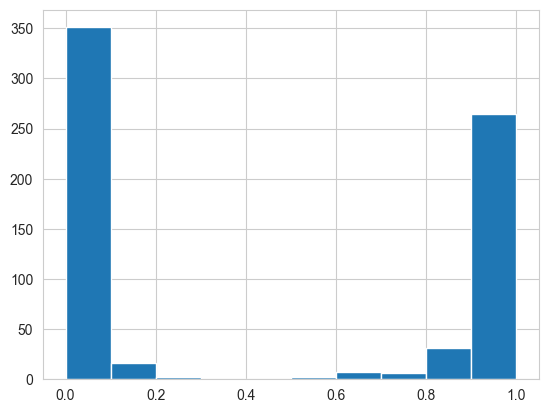

In [44]:
design_matrix_train[rate_col].hist(bins=10)

In [45]:
design_matrix_train['group'].value_counts()

group
1    369
2    311
Name: count, dtype: int64

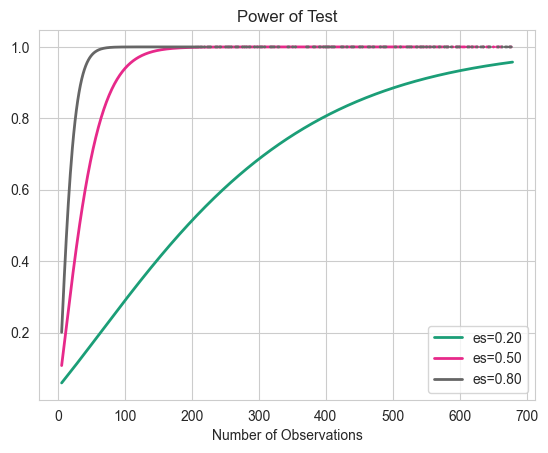

In [46]:
from statsmodels.stats.power import TTestIndPower
import matplotlib.pyplot as plt

# parameters for power analysis
effect_sizes = np.array([0.2, 0.5, 0.8])
sample_sizes = np.array(range(5, design_matrix_train.shape[0]))


analysis = TTestIndPower()

analysis.plot_power(dep_var='nobs', nobs=sample_sizes, effect_size=effect_sizes)
plt.show()

In [47]:
quant_matrix_train = preprocess_data(ms_data, design_matrix=design_matrix_train)

In [48]:
quant_matrix_train = quant_matrix_train.compare(
    method="linregress",
    comparisons=(2,1),
    min_samples_per_group=2,
    level="protein",
    multiple_testing_correction_method="fdr_tsbh"
)

In [49]:
#quant_matrix_train.write("de_results/resp_de_proteins.tsv")

In [50]:
quant_matrix_de = quant_matrix_train.to_df()

<Axes: xlabel='Log2FoldChange2-1', ylabel='-Log10CorrectedPValue2-1'>

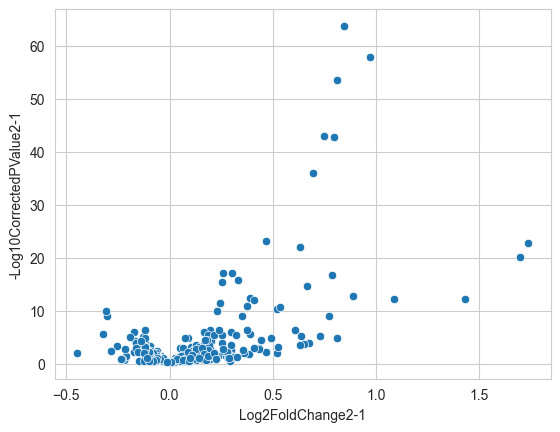

In [51]:
sns.scatterplot(
    data=quant_matrix_de,
    x="Log2FoldChange2-1",
    y="-Log10CorrectedPValue2-1"
)

In [52]:
quant_matrix_de.sort_values("CorrectedPValue2-1")

,Protein,ProteinLabel,DEScore2-1,Group2Mean,Group1Mean,Group2Stdev,Group1Stdev,Log2FoldChange2-1,PValue2-1,Group2RepCounts,...,SA_BOX_7-719_S4-E10_1_5984,SA_BOX_6-746_S2-E6_1_5853,SA_BOX_13-389_S1-B6_1_6537,SA_BOX_6-236_S2-E9_1_5878,SA_BOX_14-2043_S2-A2_1_6602,SA_BOX_11-2056_S4-F8_1_6362,SA_BOX_3-697_S4-A6_1_5555,SA_BOX_8-2367_S5-C12_1_6096,SA_BOX_4-2564_S5-F11_1_5699,SA_BOX_10-131_S2-H6_1_6249
230,P01034,CYTC_HUMAN,1.111899,12.613074,11.768951,0.654347,0.480928,0.844123,1.432566e-66,311,...,12.388361,11.367966,11.808035,12.448976,11.842510,12.033297,11.763599,12.130882,11.829693,11.762052
123,P61769,B2MG_HUMAN,1.063172,12.491123,11.522636,0.841122,0.534987,0.968487,2.529239e-60,311,...,12.652368,10.490738,11.618301,12.289228,11.372313,11.781104,10.906047,11.750655,11.657643,12.220980
80,P00746,CFAD_HUMAN,0.960440,12.029540,11.217901,0.701780,0.514878,0.811639,5.691806e-56,311,...,11.758841,11.026146,11.914894,11.783697,10.489469,11.478523,11.510933,11.364108,11.175636,11.904981
217,P39060,COIA1_HUMAN,0.800746,10.175254,9.426237,0.631625,0.645089,0.749017,3.798823e-45,311,...,9.634904,8.969382,9.303124,10.259988,9.311042,10.097311,9.641211,9.908037,9.111742,9.492980
146,P41222,PTGDS_HUMAN,0.811834,11.490478,10.695590,0.783036,0.580357,0.794888,7.147598e-45,311,...,10.507759,10.037824,10.779898,11.730896,10.193436,11.014198,10.388918,10.107603,10.411609,10.777951
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
275,P07477,TRY1_HUMAN,0.002550,14.600587,14.596243,0.619126,0.621055,0.004344,9.276314e-01,311,...,14.437476,14.946164,14.013308,14.461313,15.017907,14.680294,14.936390,14.885729,13.464894,14.594135
247,P09172,DOPO_HUMAN,0.005304,9.887000,9.877821,1.433913,1.535899,0.009179,9.363388e-01,311,...,9.846202,10.267738,10.605455,11.687354,10.988223,10.713823,10.078845,10.426473,10.027505,4.226699
3,P00450,CERU_HUMAN,0.000305,17.386812,17.386311,0.352733,0.348100,0.000501,9.852074e-01,311,...,17.833508,17.120619,17.241939,18.251753,17.263895,17.705602,17.628483,17.342026,17.519237,17.480151
70,Q96IY4,CBPB2_HUMAN,0.000262,12.969287,12.968851,0.421436,0.376293,0.000436,9.886582e-01,311,...,12.845945,13.049481,12.923929,13.482451,13.344289,13.425174,13.172045,13.378734,13.126525,13.358252


In [53]:
qm_filtered = (
    
    QuantMatrix(
        quantification_file=quant_matrix_de,
        design_matrix_file=design_matrix_train
    )
    
)

In [54]:
training_data, y = qm_filtered.to_ml(feature_column="ProteinLabel")

In [55]:
protein_columns = training_data.columns.to_list()

In [56]:
len(protein_columns)

287

In [57]:
from sklearn.preprocessing import StandardScaler, LabelBinarizer
from sklearn.impute import SimpleImputer

X = training_data.copy()

protein_scaler = StandardScaler()

X[protein_columns] = protein_scaler.fit_transform(X[protein_columns])

X = X.copy()

In [58]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import BaggingClassifier


protein_clf = LogisticRegression(
    random_state=42,
    #penalty="l1",
    class_weight="balanced",
    #C=0.1,
    #solver="liblinear",
    max_iter=1000
)

# protein_clf = BaggingClassifier(
#     estimator=protein_clf
# )

In [59]:
from sklearn.model_selection import cross_val_score, StratifiedKFold, cross_validate

cv = StratifiedKFold(3)
eval_result = cross_validate(
    protein_clf, X[protein_columns], y.values.ravel(), scoring=("recall", "precision", "accuracy", "balanced_accuracy", "roc_auc"), cv=cv, #params={"sample_weight": sample_weight}
)
eval_result['test_recall'].mean(), eval_result['test_precision'].mean(), eval_result['test_accuracy'].mean(), eval_result['test_balanced_accuracy'].mean(), eval_result['test_roc_auc'].mean()

(0.7877458302215584,
 0.7924725696880248,
 0.8073889257078997,
 0.8057970343519717,
 0.8911496060442307)

In [25]:
from dpks.interpretation import FeatureImportance
import warnings
warnings.filterwarnings("ignore")

feature_importance_results = []

for i, (train, test) in enumerate(cv.split(X, y)):

    train_data = X.iloc[train][protein_columns]
    test_data = X.iloc[test][protein_columns]

    y_train = y.iloc[train]
    y_test = y.iloc[test]

    feature_importance = FeatureImportance(
        n_iterations=100,
        feature_names=protein_columns,
    )

    protein_clf.fit(train_data[protein_columns], y_train)

    feature_importance.fit(protein_clf, train_data.to_numpy())

    feature_importances = pd.DataFrame(
        {
            "feature": protein_columns,
            f"importance {i}": feature_importance.global_explanations
        }
    ).set_index("feature")

    feature_importance_results.append(feature_importances)

feature_importance_results = pd.concat(feature_importance_results, axis=1)


In [26]:
feature_importance_results['Mean Importance'] = feature_importance_results[feature_importance_results.columns].mean(axis=1)

In [27]:
feature_importance_results.sort_values("Mean Importance", ascending=False, inplace=True)
feature_importance_results


,importance 0,importance 1,importance 2,Mean Importance
feature,,,,
CYTC_HUMAN,0.862555,0.633813,0.816605,0.770991
PTGDS_HUMAN,0.669579,0.920345,0.582132,0.724019
FA5_HUMAN,0.534686,0.897905,0.526265,0.652952
ZA2G_HUMAN,0.606115,0.611924,0.580696,0.599579
B2MG_HUMAN,0.584387,0.626733,0.545301,0.585473
...,...,...,...,...
APOM_HUMAN,0.047467,0.022211,0.013927,0.027868
CO2_HUMAN,0.000689,0.041414,0.038667,0.026923
PRDX2_HUMAN,0.001472,0.039447,0.038245,0.026388


In [28]:
feature_importance_results = feature_importance_results.reset_index()
feature_importance_results['feature'] = feature_importance_results['feature'].str.replace("_HUMAN", "")

In [29]:
import colorcet as cc

In [30]:
colormap = cc.glasbey_cool

In [31]:
color = colormap[1]

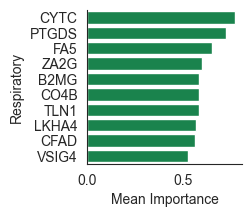

In [32]:
sns.set_style("white")

fig, ax = plt.subplots()

sns.barplot(
    data=feature_importance_results.reset_index().head(10),
    x="Mean Importance",
    y="feature",
    ax=ax,
    color=color,
)

ax.set_ylabel("Respiratory")
sns.despine()
fig.set_size_inches(
    (2, 2)
)

In [33]:
feature_importance_results["Panel"] = "Renal"

In [34]:
feature_importance_results.to_csv(
    "renal_importance.tsv",
    sep="\t",
    index=False
)

In [35]:
from joblib import dump


with open("models/renal_protein_model.pkl", "wb") as f:

    dump(protein_clf, f)

with open("models/renal_protein_scaler.pkl", "wb") as f:

    dump(protein_scaler, f)
